In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/pollution/1pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])



# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.233445
2014-07-04 20:00:00,1.030872,0.439900
2014-07-04 21:00:00,0.789484,1.121811
2014-07-04 22:00:00,0.559069,0.727420
2014-07-04 23:00:00,0.613930,0.509601


In [ ]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/pollution/1pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.323530
2014-07-04 20:00:00,1.030872,0.451096
2014-07-04 21:00:00,0.789484,1.185604
2014-07-04 22:00:00,0.559069,0.793328
2014-07-04 23:00:00,0.613930,0.604481


In [ ]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/pollution/1pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.299435
2014-07-04 20:00:00,1.030872,0.400219
2014-07-04 21:00:00,0.789484,1.157827
2014-07-04 22:00:00,0.559069,0.757885
2014-07-04 23:00:00,0.613930,0.602461


In [ ]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/pollution/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.274503
2014-07-04 20:00:00,1.030872,0.326384
2014-07-04 21:00:00,0.789484,1.113818
2014-07-04 22:00:00,0.559069,0.726848
2014-07-04 23:00:00,0.613930,0.531484


In [ ]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/pollution/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.260313
2014-07-04 20:00:00,1.030872,0.164478
2014-07-04 21:00:00,0.789484,1.082800
2014-07-04 22:00:00,0.559069,0.744419
2014-07-04 23:00:00,0.613930,0.498645


In [ ]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/1paso/pollution/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 4468 - 4337
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-07-04 19:00:00,0.526152,1.245055
2014-07-04 20:00:00,1.030872,0.306135
2014-07-04 21:00:00,0.789484,1.133229
2014-07-04 22:00:00,0.559069,0.686372
2014-07-04 23:00:00,0.613930,0.471507


## MLP ##

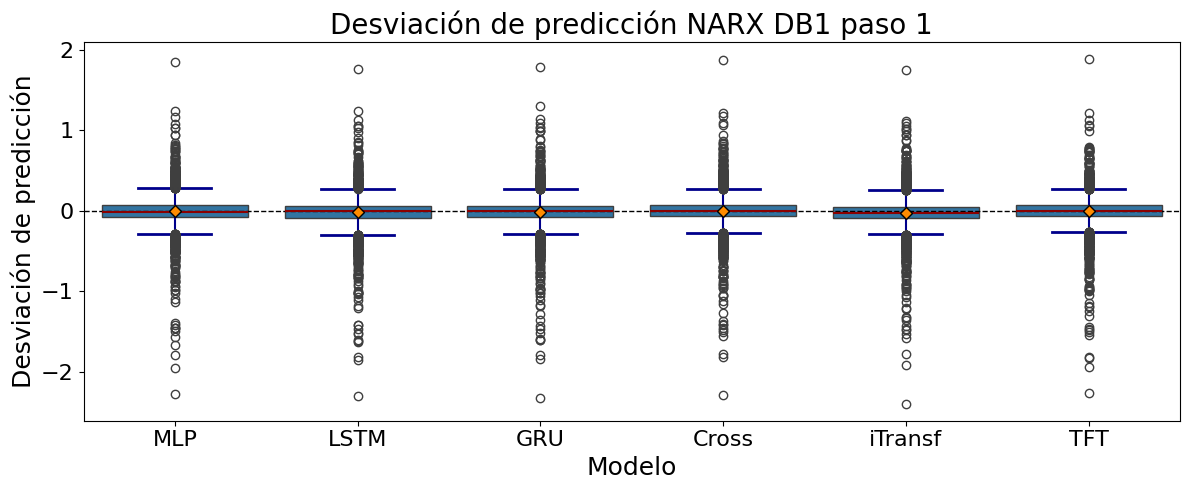

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción NARX DB1 paso 1', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda


plt.tight_layout()
plt.show()


# Graficos Q-Q

In [ ]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-07-04 19:00:00,-0.707292,-0.797377,-0.773283,-0.748350,-0.734161,-0.718902
2014-07-04 20:00:00,0.590972,0.579776,0.630654,0.704488,0.866394,0.724737
2014-07-04 21:00:00,-0.332327,-0.396119,-0.368342,-0.324334,-0.293316,-0.343744
2014-07-04 22:00:00,-0.168352,-0.234259,-0.198816,-0.167779,-0.185350,-0.127303
2014-07-04 23:00:00,0.104329,0.009448,0.011469,0.082446,0.115285,0.142423


In [ ]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [ ]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-08-14 04:00:00,-0.098546,-0.055168,-0.075553,-0.076579,-0.054500,-0.069708
2014-07-05 12:00:00,-0.228932,-0.238981,-0.247548,-0.247563,-0.252758,-0.239549
2014-12-24 16:00:00,0.011117,0.010196,0.013874,0.046171,-0.022793,0.029496
2014-10-20 07:00:00,0.073285,-0.034090,-0.030375,0.019899,0.019304,0.018036
2014-09-27 07:00:00,0.092537,0.091535,0.075822,0.070375,0.020248,0.087612


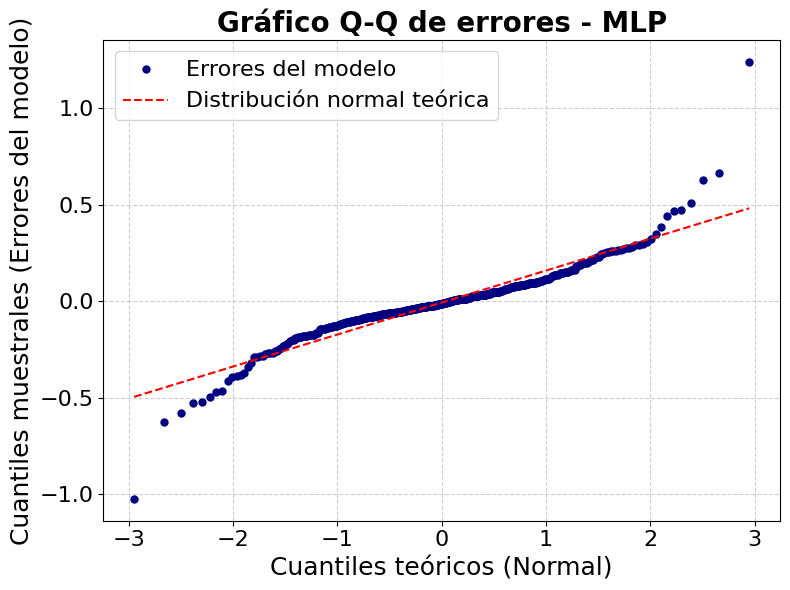

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


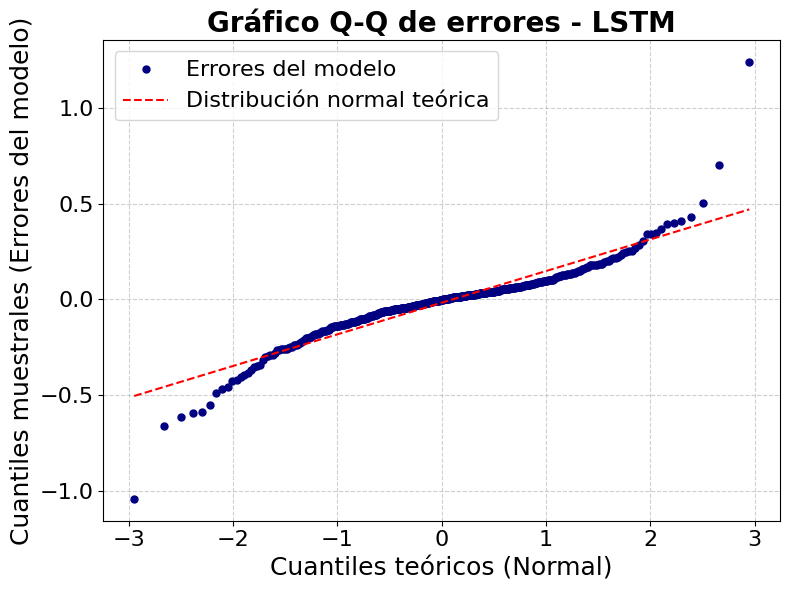

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


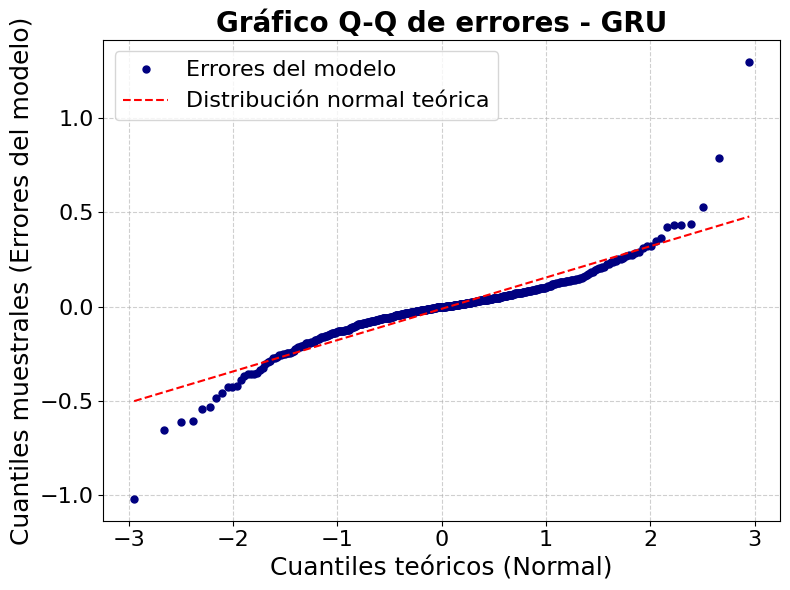

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


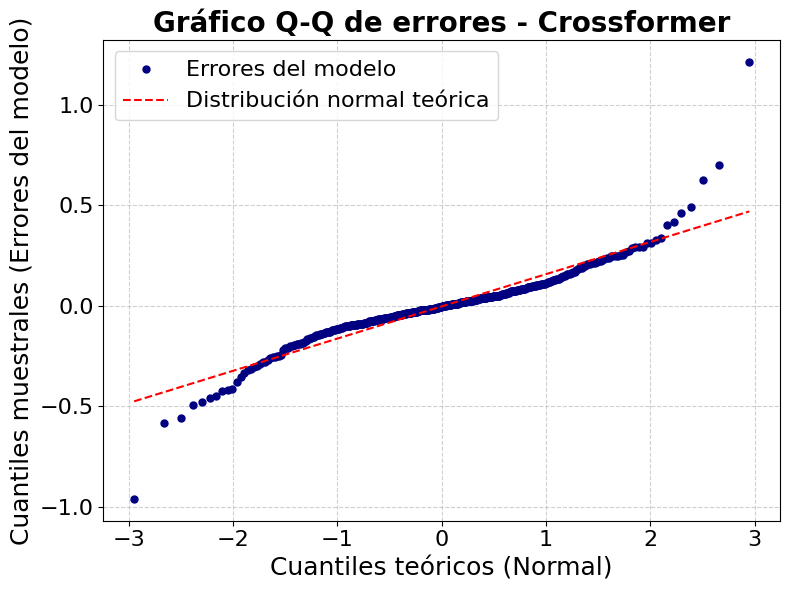

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


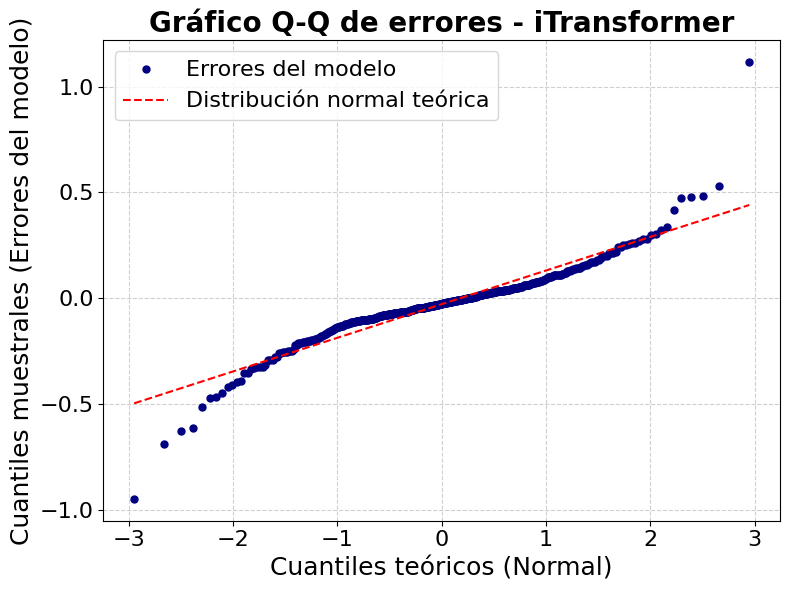

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


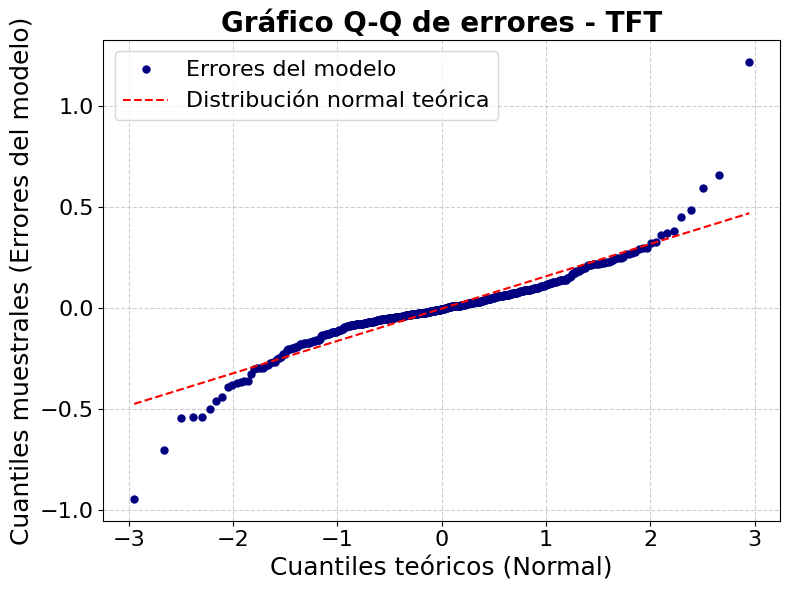

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

meses = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
def formatear_mes(x, pos):
    fecha = mdates.num2date(x)
    return meses.get(fecha.month, '')

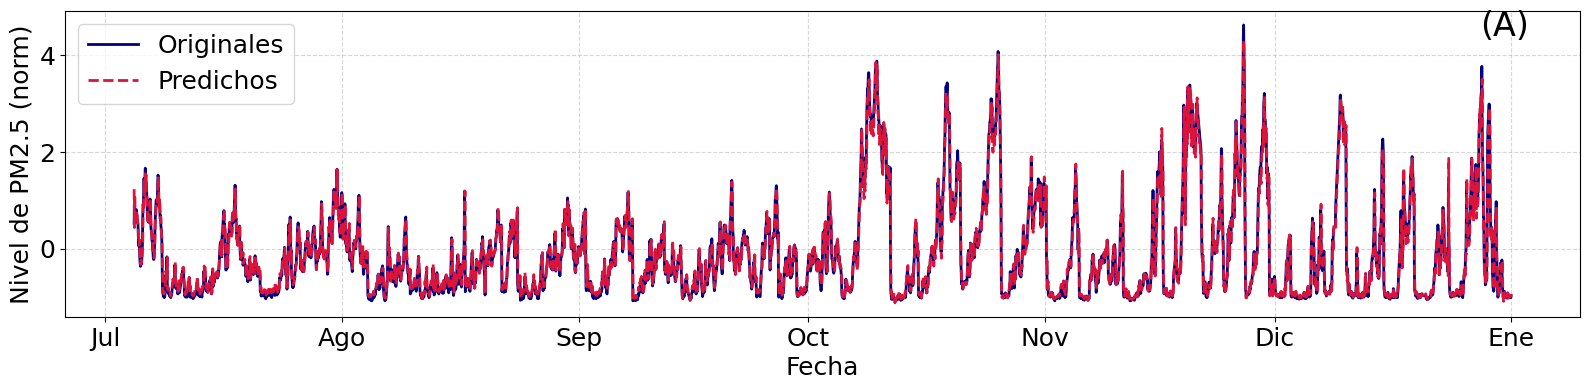

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosMLP

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


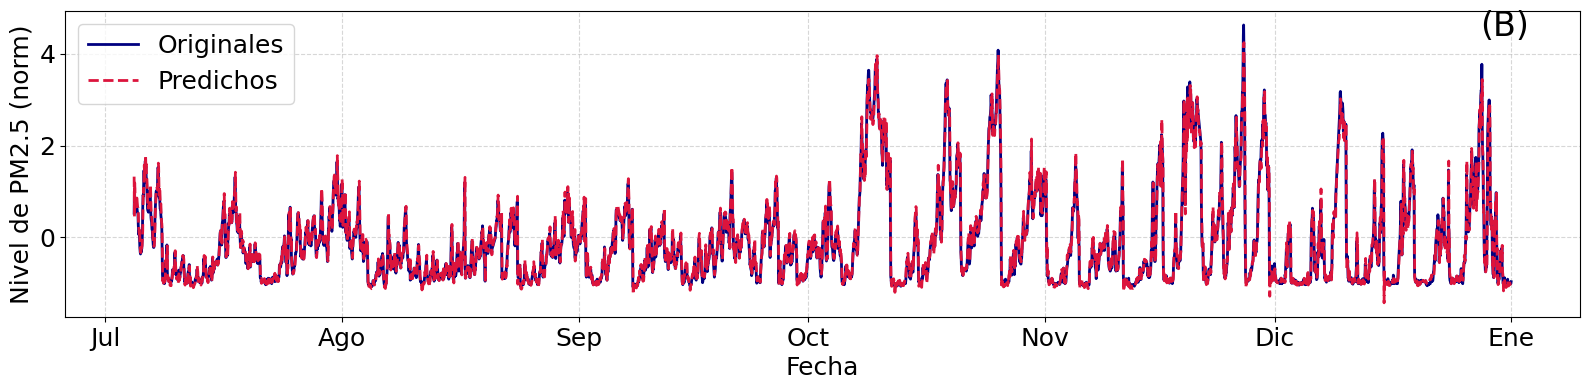

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosLSTM

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


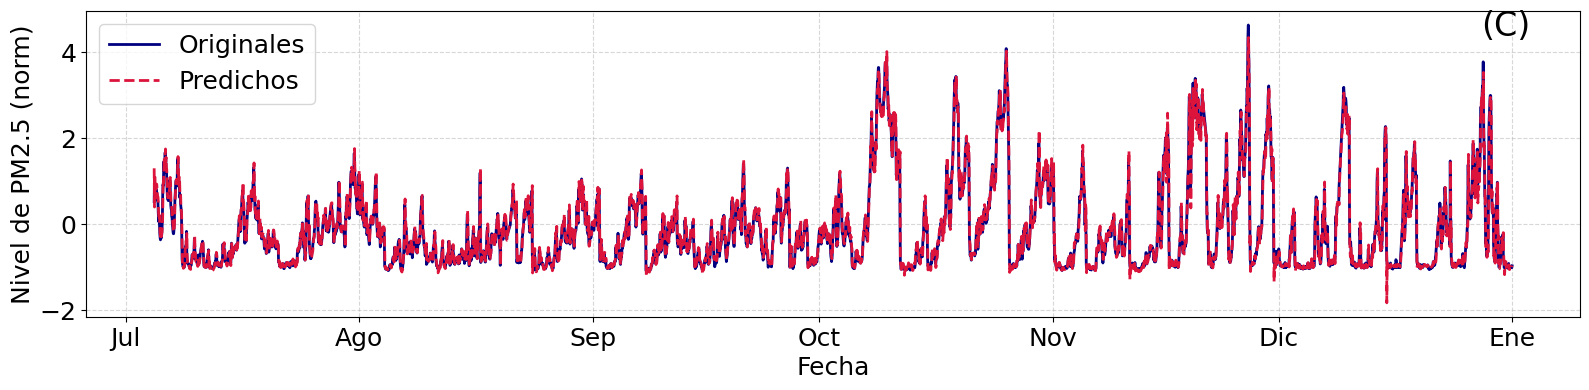

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosGRU

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


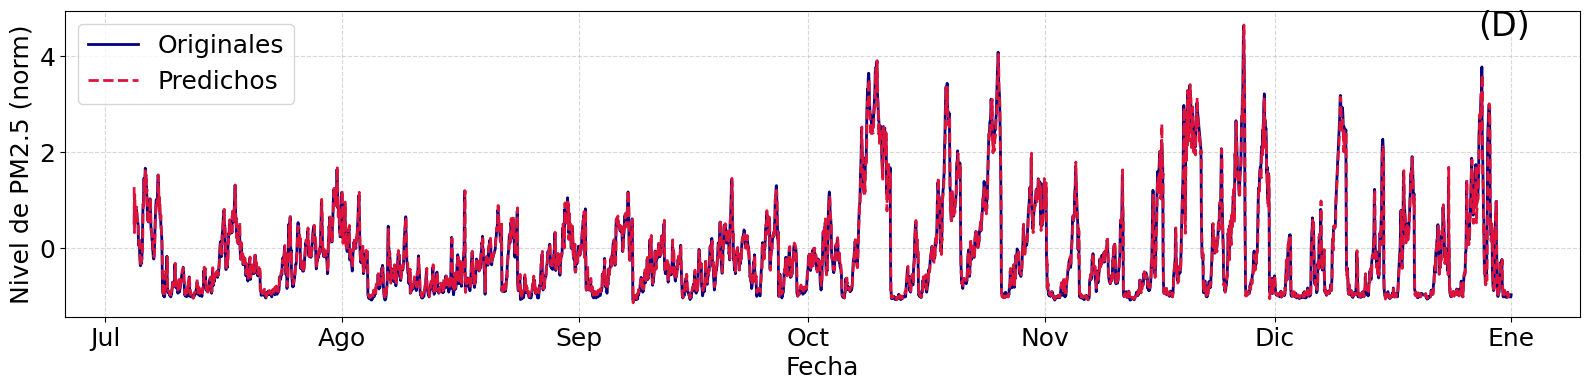

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosCross

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


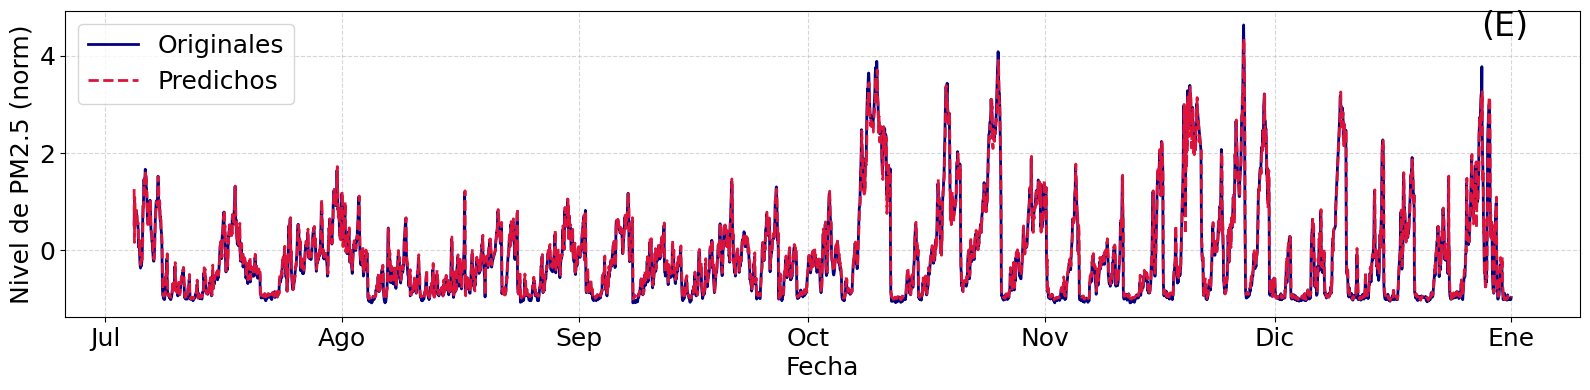

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosI

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


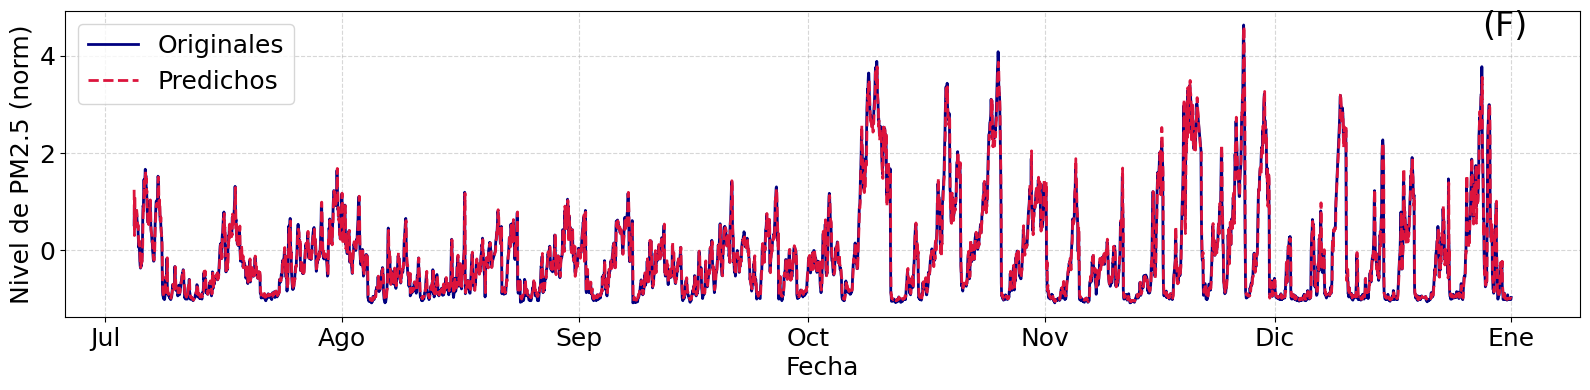

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosTFT

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, linestyle='--', label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


# Métricas

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [ ]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.03786836050050448
RMSE: 0.19459794577668205
MAE: 0.11772503830441823
SMAPE: 0.3174549721476954
IA: 0.9182634816764923


In [ ]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.03882689199758049
RMSE: 0.19704540592863487
MAE: 0.11684866329353147
SMAPE: 0.31569063377751616
IA: 0.920527753027945


In [ ]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.03867895729765323
RMSE: 0.19666966542314865
MAE: 0.11622939031166296
SMAPE: 0.3150530493802181
IA: 0.920879959667728


In [ ]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.03804320225677096
RMSE: 0.19504666686916483
MAE: 0.11630535169596068
SMAPE: 0.3132969257721926
IA: 0.9196013630271914


In [ ]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.039103464236569956
RMSE: 0.1977459588375195
MAE: 0.11944823667586359
SMAPE: 0.3242024465544294
IA: 0.9170001495810173


In [ ]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.03764028674036899
RMSE: 0.19401104798533766
MAE: 0.11372692552521264
SMAPE: 0.3113632464680178
IA: 0.9218784120986633


# Pruebas de significación

In [ ]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [ ]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT:", p)


MLP: 8.764463542648186e-50
LSTM: 2.9898292770493364e-53
GRU: 1.2364566064639535e-50
Cross: 8.758424554220809e-51
iTransf: 5.454429828248548e-53
TFT: 4.746217599884386e-51


In [ ]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

1.0900736011753902e-27


In [ ]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00061,0.00912,0.00426
1,MLP vs GRU,0.04542,0.68126,0.09083
2,MLP vs Crossformer,0.04732,0.70978,0.09083
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.00399,0.05986,0.01197
5,LSTM vs GRU,0.00048,0.00715,0.00381
6,LSTM vs Crossformer,0.00002,0.00027,0.00018
7,LSTM vs iTransformer,0.00144,0.02165,0.00866
8,LSTM vs TFT,0.00000,0.00000,0.00000
9,GRU vs Crossformer,0.00149,0.02229,0.00866
